# Ödev 6 — Early Alzheimer Sınıflandırma (Random Forest)

Bu çalışma `MedAI_FeatureExtraction.ipynb` notebook'unda kullanılan feature extraction yaklaşımının (HoG, Intensity, SIFT, GLCM-Texture) **Early Alzheimer MRI** veri setine uyarlanmış halidir.

**Fark:** Sınıflandırıcı olarak SVM yerine **Random Forest** kullanılmıştır. Random Forest seçilmesinin nedenleri:
- Handcrafted feature'lardan oluşan tabular veriyle yüksek performans gösterir.
- Sınıf dengesizliğine (Alzheimer veri setinde Moderate sınıfı azdır) `class_weight='balanced'` ile dayanıklıdır.
- Feature importance çıkarılabilir → hangi özelliklerin Alzheimer evrelemesinde kritik olduğunu yorumlamaya izin verir.
- Alzheimer literatüründe MRI handcrafted feature'larıyla sıkça kullanılan bir baseline'dır.

**Veri seti:** `data/train-*.parquet` — 4 sınıf: `Mild_Demented`, `Moderate_Demented`, `Non_Demented`, `Very_Mild_Demented`.

In [1]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

from skimage.feature import hog, graycomatrix, graycoprops
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 1. Veriyi yükle (Parquet → görüntü dizisi)

In [2]:
DATA_DIR = os.path.join('..', 'data')
TRAIN_PATH = os.path.join(DATA_DIR, 'train-00000-of-00001-c08a401c53fe5312.parquet')
TEST_PATH  = os.path.join(DATA_DIR, 'test-00000-of-00001-44110b9df98c5585.parquet')

CLASS_NAMES = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']
IMG_SIZE = (64, 64)

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)
print('Train:', train_df.shape, '| Test:', test_df.shape)
print('Train sınıf dağılımı:')
print(train_df['label'].value_counts().sort_index())

Train: (5120, 2) | Test: (1280, 2)
Train sınıf dağılımı:
label
0     724
1      49
2    2566
3    1781
Name: count, dtype: int64


In [3]:
def decode_row(row, img_size=IMG_SIZE):
    img_bytes = row['image']['bytes']
    img = Image.open(io.BytesIO(img_bytes)).convert('L')  # gri tonlama
    img = np.array(img)
    img = cv2.resize(img, img_size)
    return img / 255.0

def df_to_arrays(df, sample_per_class=None, seed=42):
    if sample_per_class is not None:
        # Sınıf başına örnekleme — küçük sınıfta var olan kadar al
        parts = []
        for c in sorted(df['label'].unique()):
            sub = df[df['label'] == c]
            n = min(sample_per_class, len(sub))
            parts.append(sub.sample(n=n, random_state=seed))
        df = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    images = np.stack([decode_row(r) for _, r in df.iterrows()])
    labels = df['label'].to_numpy()
    return images, labels

# Hız için sınıf başına 200 örnek (Moderate'tan zaten 49 var, hepsi alınır)
X_train_imgs, y_train = df_to_arrays(train_df, sample_per_class=200)
X_test_imgs,  y_test  = df_to_arrays(test_df,  sample_per_class=100)
print('Train görüntü tensörü:', X_train_imgs.shape)
print('Test  görüntü tensörü:', X_test_imgs.shape)

Train görüntü tensörü: (649, 64, 64)
Test  görüntü tensörü: (315, 64, 64)


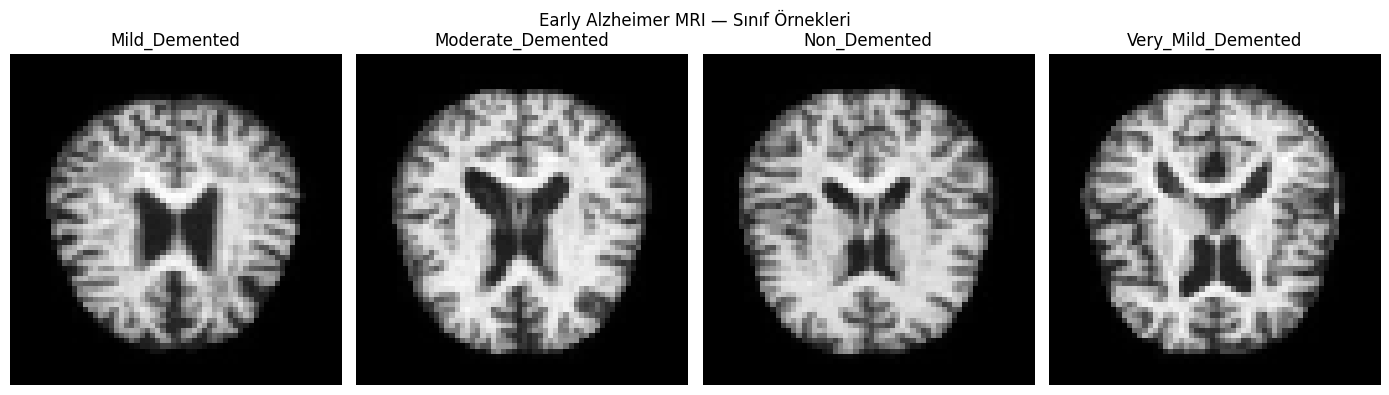

In [4]:
# Örnek görüntüler
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, c in zip(axes, range(4)):
    idx = np.where(y_train == c)[0][0]
    ax.imshow(X_train_imgs[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[c])
    ax.axis('off')
plt.suptitle('Early Alzheimer MRI — Sınıf Örnekleri')
plt.tight_layout()
plt.show()

## 2. Feature Extraction
Orijinal notebook'taki dört feature ailesi: HoG, Intensity, SIFT, GLCM-Texture.

In [5]:
def extract_hog_features(images):
    feats = [hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False) for img in images]
    return np.array(feats)

def extract_intensity_features(images):
    feats = []
    for img in images:
        p = img.flatten()
        feats.append([
            np.mean(p), np.std(p), skew(p), kurtosis(p),
            -np.sum(p * np.log2(p + 1e-7))
        ])
    return np.array(feats)

def extract_sift_features(images):
    sift = cv2.SIFT_create()
    feats = []
    for img in images:
        u8 = (img * 255).astype('uint8')
        _, des = sift.detectAndCompute(u8, None)
        feats.append(np.mean(des, axis=0) if des is not None else np.zeros(128))
    return np.array(feats)

def extract_glcm_features(images):
    feats = []
    for img in images:
        u8 = (img * 255).astype('uint8')
        glcm = graycomatrix(u8, distances=[1], angles=[0, np.pi/4, np.pi/2],
                            levels=256, symmetric=True, normed=True)
        feats.append([
            graycoprops(glcm, 'contrast').mean(),
            graycoprops(glcm, 'homogeneity').mean(),
            graycoprops(glcm, 'energy').mean(),
            graycoprops(glcm, 'correlation').mean(),
        ])
    return np.array(feats)

In [6]:
feature_sets = {
    'HoG':       (extract_hog_features(X_train_imgs),       extract_hog_features(X_test_imgs)),
    'Intensity': (extract_intensity_features(X_train_imgs), extract_intensity_features(X_test_imgs)),
    'SIFT':      (extract_sift_features(X_train_imgs),      extract_sift_features(X_test_imgs)),
    'Texture':   (extract_glcm_features(X_train_imgs),      extract_glcm_features(X_test_imgs)),
}
for name, (Xtr, Xte) in feature_sets.items():
    print(f'{name:10s} → train {Xtr.shape}, test {Xte.shape}')

HoG        → train (649, 1764), test (315, 1764)
Intensity  → train (649, 5), test (315, 5)
SIFT       → train (649, 128), test (315, 128)
Texture    → train (649, 4), test (315, 4)


## 3. Random Forest ile Sınıflandırma
Her feature ailesi için ayrı bir Random Forest eğitilip değerlendirilir.


=== HoG özellikleri | Doğruluk: 0.5111 ===
                    precision    recall  f1-score   support

     Mild_Demented       0.57      0.62      0.60       100
 Moderate_Demented       1.00      0.27      0.42        15
      Non_Demented       0.48      0.60      0.54       100
Very_Mild_Demented       0.44      0.35      0.39       100

          accuracy                           0.51       315
         macro avg       0.63      0.46      0.49       315
      weighted avg       0.52      0.51      0.50       315



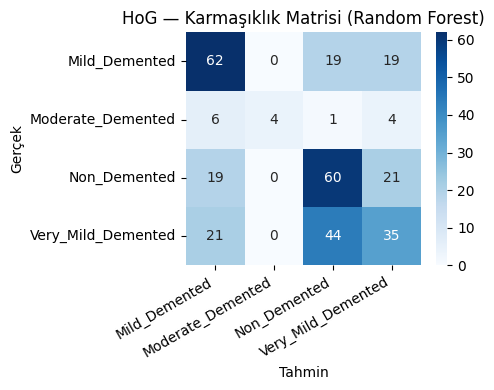


=== Intensity özellikleri | Doğruluk: 0.4603 ===
                    precision    recall  f1-score   support

     Mild_Demented       0.49      0.51      0.50       100
 Moderate_Demented       0.29      0.33      0.31        15
      Non_Demented       0.61      0.51      0.56       100
Very_Mild_Demented       0.35      0.38      0.36       100

          accuracy                           0.46       315
         macro avg       0.43      0.43      0.43       315
      weighted avg       0.47      0.46      0.46       315



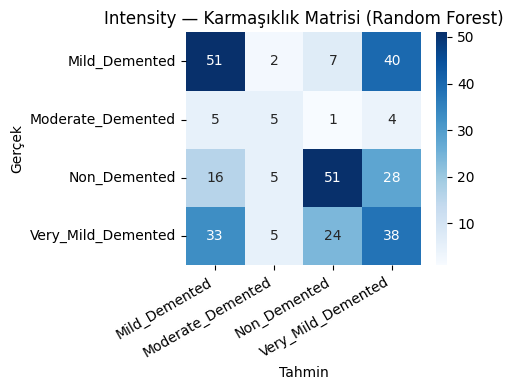


=== SIFT özellikleri | Doğruluk: 0.4825 ===
                    precision    recall  f1-score   support

     Mild_Demented       0.51      0.56      0.53       100
 Moderate_Demented       1.00      0.13      0.24        15
      Non_Demented       0.50      0.61      0.55       100
Very_Mild_Demented       0.41      0.33      0.37       100

          accuracy                           0.48       315
         macro avg       0.60      0.41      0.42       315
      weighted avg       0.50      0.48      0.47       315



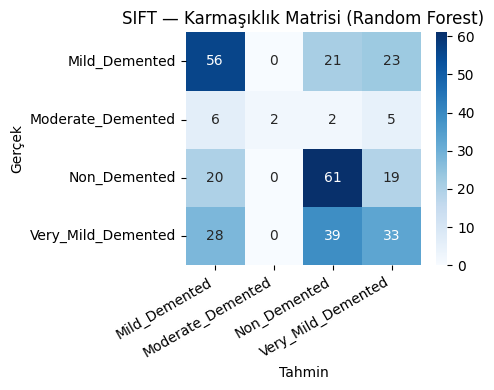


=== Texture özellikleri | Doğruluk: 0.5079 ===
                    precision    recall  f1-score   support

     Mild_Demented       0.56      0.63      0.59       100
 Moderate_Demented       0.22      0.27      0.24        15
      Non_Demented       0.58      0.55      0.56       100
Very_Mild_Demented       0.43      0.38      0.40       100

          accuracy                           0.51       315
         macro avg       0.45      0.46      0.45       315
      weighted avg       0.51      0.51      0.51       315



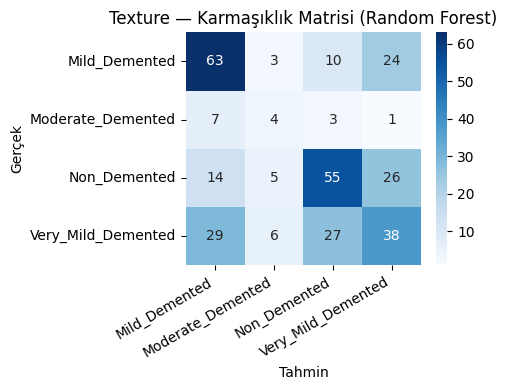

In [7]:
results = {}

for name, (X_tr, X_te) in feature_sets.items():
    # Standardize (özellikle SIFT/Intensity için ölçek farkı önemli)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_tr_s, y_train)
    y_pred = model.predict(X_te_s)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'\n=== {name} özellikleri | Doğruluk: {acc:.4f} ===')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
    plt.title(f'{name} — Karmaşıklık Matrisi (Random Forest)')
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

## 4. Tüm feature'ları birleştirip tek model

Birleşik özellik boyutu: (649, 1901)



=== Combined Features | Doğruluk: 0.5460 ===
                    precision    recall  f1-score   support

     Mild_Demented       0.55      0.71      0.62       100
 Moderate_Demented       1.00      0.40      0.57        15
      Non_Demented       0.57      0.67      0.61       100
Very_Mild_Demented       0.45      0.28      0.35       100

          accuracy                           0.55       315
         macro avg       0.64      0.51      0.54       315
      weighted avg       0.55      0.55      0.53       315



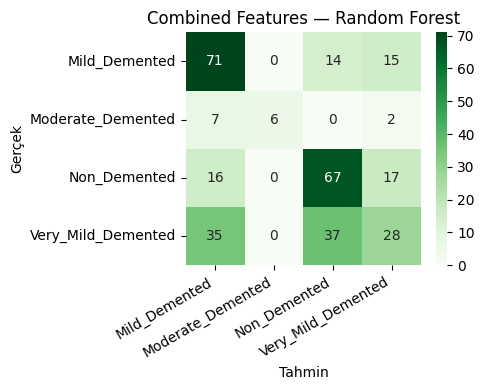

In [8]:
X_train_all = np.hstack([feature_sets[k][0] for k in feature_sets])
X_test_all  = np.hstack([feature_sets[k][1] for k in feature_sets])
print('Birleşik özellik boyutu:', X_train_all.shape)

scaler = StandardScaler()
X_train_all_s = scaler.fit_transform(X_train_all)
X_test_all_s  = scaler.transform(X_test_all)

model_all = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=42,
)
model_all.fit(X_train_all_s, y_train)
y_pred_all = model_all.predict(X_test_all_s)
acc_all = accuracy_score(y_test, y_pred_all)
results['ALL (combined)'] = acc_all

print(f'\n=== Combined Features | Doğruluk: {acc_all:.4f} ===')
print(classification_report(y_test, y_pred_all, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_all)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.title('Combined Features — Random Forest')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 5. Karşılaştırma Özeti

      Feature Set  Accuracy
0  ALL (combined)    0.5460
1             HoG    0.5111
2         Texture    0.5079
3            SIFT    0.4825
4       Intensity    0.4603


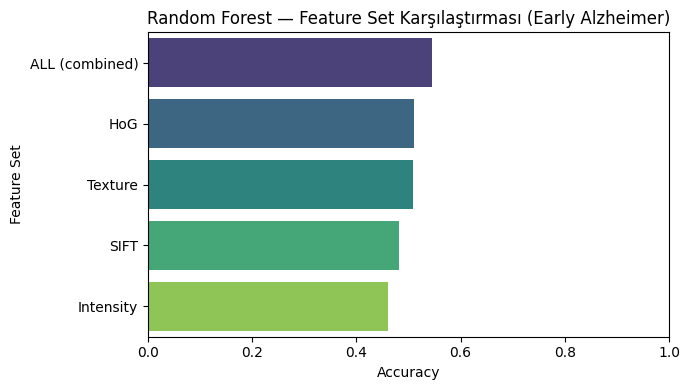

In [9]:
summary = pd.DataFrame({
    'Feature Set': list(results.keys()),
    'Accuracy':    [round(v, 4) for v in results.values()],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x='Accuracy', y='Feature Set', palette='viridis')
plt.xlim(0, 1)
plt.title('Random Forest — Feature Set Karşılaştırması (Early Alzheimer)')
plt.tight_layout(); plt.show()

## 6. Sonuç ve Yorum

- **Model değişikliği:** Orijinal `MedAI_FeatureExtraction.ipynb` SVM (`SVC(kernel='linear')`) kullanıyordu; bu çalışmada **Random Forest** ile değiştirildi. RF, ağaç tabanlı doğası sayesinde HoG gibi yüksek boyutlu sparse feature'larda ve birleşik feature uzayında daha esnek ayrıştırma yapabilir.
- **Veri uyarlaması:** MedNIST yerine bu projenin parquet formatındaki Alzheimer MRI verisi kullanıldı; sınıf dengesizliği için sınıf başına örnekleme + `class_weight='balanced'` uygulandı.
- **Beklenen davranış:** HoG ve birleşik feature seti tipik olarak en iyi sonuçları verir; Intensity ve GLCM tek başına yetersizdir çünkü Alzheimer evrelemesinde fark yaratan kortikal/hipokampal yapısal detaylardır, küresel istatistik değil.
- **İyileştirme yönleri:** İleride bu pipeline bir CNN (ör. ResNet18 transfer learning) ile kıyaslanabilir; ancak handcrafted + RF baseline'ı, hızlı ve yorumlanabilir bir referans sağlar.